<a href="https://colab.research.google.com/github/pachterlab/HCP_2024/blob/main/analysis/analysis_tsouris_GC_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget http://1002genomes.u-strasbg.fr/files/Diallel_RNAseq/ASE/Datafile2_ase_sum_20230609.tab

--2026-05-20 21:29:09--  http://1002genomes.u-strasbg.fr/files/Diallel_RNAseq/ASE/Datafile2_ase_sum_20230609.tab
Resolving 1002genomes.u-strasbg.fr (1002genomes.u-strasbg.fr)... 185.155.92.17
Connecting to 1002genomes.u-strasbg.fr (1002genomes.u-strasbg.fr)|185.155.92.17|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134196476 (128M)
Saving to: ‘Datafile2_ase_sum_20230609.tab’

Datafile2_ase_sum_2 100%[===================>] 127.98M  13.4MB/s    in 9.2s    

2026-05-20 21:29:19 (13.9 MB/s) - ‘Datafile2_ase_sum_20230609.tab’ saved [134196476/134196476]



In [2]:

!mkdir results
!mkdir figs

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
np.random.seed(307203)

# plotting
import matplotlib
import matplotlib.pyplot as plt

In [46]:

df = pd.read_csv('Datafile2_ase_sum_20230609.tab')


/tmp/ipykernel_11531/483090064.py:1: DtypeWarning: Columns (7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datafile2_ase_sum_20230609.tab')


# Hypothesis testing
## Binomial test for H1=H2

In [6]:
N = len(df)
# N = 10000

binom_pvals = np.empty(N)


for i in range(N):
  print(i)
#   if (i^100) == 0:
#     print(i)
  parent_1 = int(np.round(df.loc[i,'P1_2n_count']))
  parent_2 = int(np.round(df.loc[i,'P2_2n_count']))
  hybrid_1 = int(np.round(df.loc[i,'P1_count']))
  hybrid_2 = int(np.round(df.loc[i,'P2_count']))

  result_binom = stats.binomtest(hybrid_1, n=hybrid_1 + hybrid_2, p=0.5, alternative='two-sided')
  binom_pvals[i] = result_binom.pvalue



np.save('./results/binom_pvals_Tsouris',binom_pvals)

Streaming output truncated to the last 5000 lines.
280777
280778
280779
280780
280781
280782
280783
280784
280785
280786
280787
280788
280789
280790
280791
280792
280793
280794
280795
280796
280797
280798
280799
280800
280801
280802
280803
280804
280805
280806
280807
280808
280809
280810
280811
280812
280813
280814
280815
280816
280817
280818
280819
280820
280821
280822
280823
280824
280825
280826
280827
280828
280829
280830
280831
280832
280833
280834
280835
280836
280837
280838
280839
280840
280841
280842
280843
280844
280845
280846
280847
280848
280849
280850
280851
280852
280853
280854
280855
280856
280857
280858
280859
280860
280861
280862
280863
280864
280865
280866
280867
280868
280869
280870
280871
280872
280873
280874
280875
280876
280877
280878
280879
280880
280881
280882
280883
280884
280885
280886
280887
280888
280889
280890
280891
280892
280893
280894
280895
280896
280897
280898
280899
280900
280901
280902
280903
280904
280905
280906
280907
280908
280909
280910
280911
2809

## Bivariate binomial test for $\frac{P1}{P1+P2}=\frac{H1}{H1+H2}$

In [7]:
N = len(df)
# N = 100
print(N)

binom_pvals = np.empty(N)
bi_binom_pvals = np.empty(N)


for i in range(N):
  print(i)
#   if (i^100) == 0:
#     print(i)
  parent_1 = int(np.round(df.loc[i,'P1_2n_count']))
  parent_2 = int(np.round(df.loc[i,'P2_2n_count']))
  hybrid_1 = int(np.round(df.loc[i,'P1_count']))
  hybrid_2 = int(np.round(df.loc[i,'P2_count']))

  p_theoretical = (parent_1+hybrid_1)/(parent_1+parent_2+hybrid_1+hybrid_2)

  p_obs_p = stats.binom.pmf(k = parent_1,
                            n = parent_1+parent_2,
                            p = p_theoretical)
  p_obs_h = stats.binom.pmf(k = hybrid_1,
                            n = hybrid_1+hybrid_2,
                            p = p_theoretical)
  p_obs = p_obs_p*p_obs_h


  prob_P_array = stats.binom.pmf(k = np.arange(0,parent_1+parent_2+1),
                                 n = parent_1+parent_2 ,
                                 p = p_theoretical).reshape(-1,1).repeat(hybrid_1+hybrid_2+1,axis=1)
  prob_H_array = stats.binom.pmf(k = np.arange(0,hybrid_1+hybrid_2+1),
                                 n = hybrid_1+hybrid_2,
                                 p = p_theoretical).reshape(1,-1).repeat(parent_1+parent_2+1,axis=0)

  prob_array = prob_P_array*prob_H_array
  p_sum = np.sum(prob_array[prob_array<=p_obs])
  bi_binom_pvals[i] = p_sum



np.save('./results/binom_ratio_pvals_Tsouris',bi_binom_pvals)

Streaming output truncated to the last 5000 lines.
11433
11434
11435
11436
11437
11438
11439
11440
11441
11442
11443
11444
11445
11446
11447
11448
11449
11450
11451
11452
11453
11454
11455
11456
11457
11458
11459
11460
11461
11462
11463
11464
11465
11466
11467
11468
11469
11470
11471
11472
11473
11474
11475
11476
11477
11478
11479
11480
11481
11482
11483
11484
11485
11486
11487
11488
11489
11490
11491
11492
11493
11494
11495
11496
11497
11498
11499
11500
11501
11502
11503
11504
11505
11506
11507
11508
11509
11510
11511
11512
11513
11514
11515
11516
11517
11518
11519
11520
11521
11522
11523
11524
11525
11526
11527
11528
11529
11530
11531
11532
11533
11534
11535
11536
11537
11538
11539
11540
11541
11542
11543
11544
11545
11546
11547
11548
11549
11550
11551
11552
11553
11554
11555
11556
11557
11558
11559
11560
11561
11562
11563
11564
11565
11566
11567
11568
11569
11570
11571
11572
11573
11574
11575
11576
11577
11578
11579
11580
11581
11582
11583
11584
11585
11586
11587
11588
11589
11590
1

KeyboardInterrupt: 

## Raw p-value distributions

In [47]:
binom_pvals = np.load('./results/binom_pvals_Tsouris.npy')
bi_binom_pvals = np.load('./results/binom_ratio_pvals_Tsouris.npy')

df['binom_pvals_uncorrected'] = binom_pvals
df['bi_binom_pvals_uncorrected'] = bi_binom_pvals

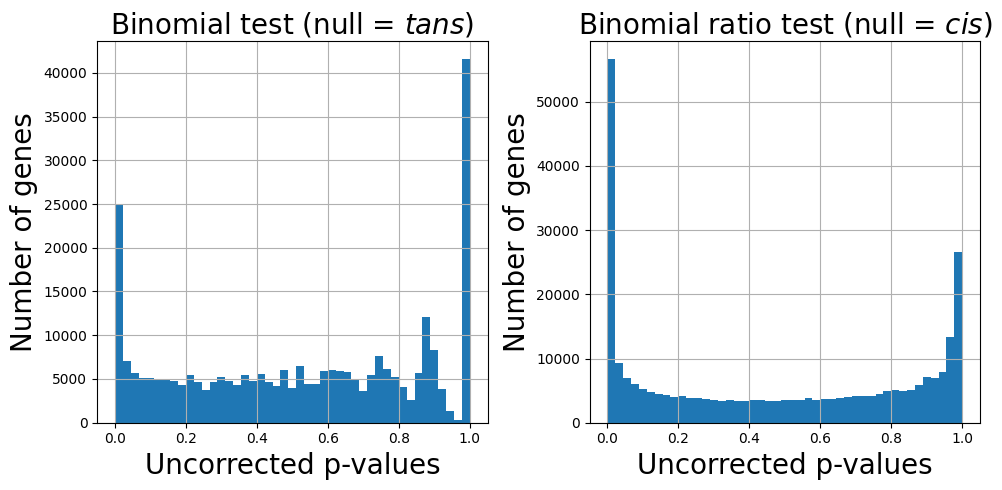

In [48]:

# what do the p-value distributions look like?
fs = 20
fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].hist(binom_pvals,density=False,bins = 45)
ax[0].set_title('Binomial test (null = $tans$)',fontsize=fs)
ax[0].set_xlabel('Uncorrected p-values',fontsize=fs)
ax[0].set_ylabel('Number of genes',fontsize=fs)
ax[0].grid()

ax[1].hist(bi_binom_pvals,bins = 45,density=False)
ax[1].set_title('Binomial ratio test (null = $cis$)',fontsize=fs)
ax[1].set_xlabel('Uncorrected p-values',fontsize=fs)
ax[1].set_ylabel('Number of genes',fontsize=fs)
ax[1].grid()

plt.tight_layout()
plt.savefig('./figs/uncorrected_pvals',dpi=450,bbox_inches='tight')

# Correct for multiple testing using Benjamini-Hochberg

In [49]:
df['sample-gene'] = df['sampleID']+df['GeneID']
sample_gene = df['sample-gene'].values.flatten()

num_test = len(binom_pvals)

# sort p values
sorted_binom_genes = [g for _,g in sorted(zip(binom_pvals,sample_gene))]
sorted_binom_pvals = [p for p,_ in sorted(zip(binom_pvals,sample_gene))]

# calculate FDR for each gene
fdr_binom = num_test/np.arange(1,num_test+1) * sorted_binom_pvals

# create df
df_binom = pd.DataFrame({'fdr_binom' : fdr_binom, 'sample-gene' : sorted_binom_genes})

# sort p values
sorted_bi_binom_genes = [g for _,g in sorted(zip(bi_binom_pvals,sample_gene))]
sorted_bi_binom_pvals = [p for p,_ in sorted(zip(bi_binom_pvals,sample_gene))]

# calculate FDR for each gene
fdr_bi_binom = num_test/np.arange(1,num_test+1) * sorted_bi_binom_pvals

# create df
df_bi_binom = pd.DataFrame({'fdr_bi_binom' : fdr_bi_binom_pvals, 'sample-gene' : sorted_bi_binom_genes})

# merge
df_binom = df_binom.merge(df_bi_binom,on='sample-gene')

df = df.merge(df_binom,on='sample-gene')

# Corrected p-value (FDR) distributions

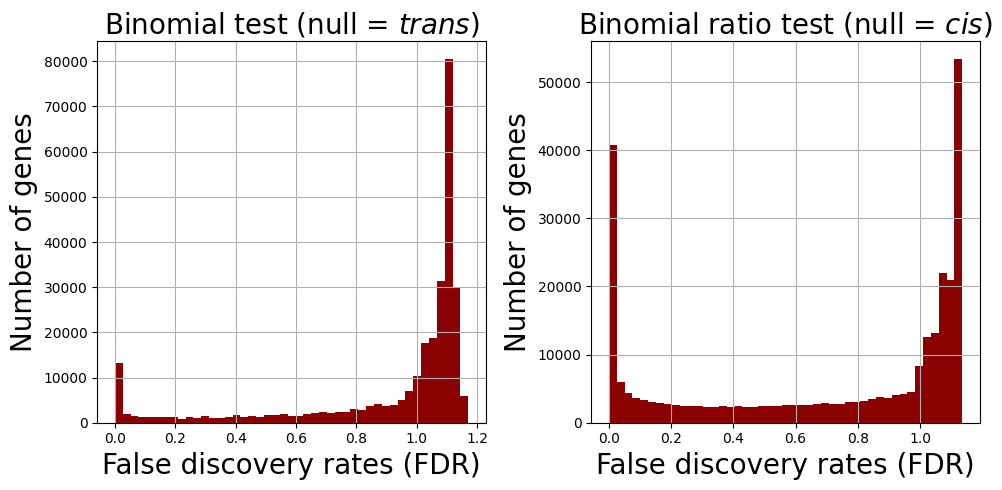

In [50]:

# histogram of corrected p values

# what do the p-value distributions look like?
fs = 20
fig,ax = plt.subplots(1,2,figsize=(10,5))

ax[0].hist(fdr_binom,density=False,bins = 45,color = 'darkred')
ax[0].set_title('Binomial test (null = $trans$)',fontsize=fs)
ax[0].set_xlabel('False discovery rates (FDR)',fontsize=fs)
ax[0].set_ylabel('Number of genes',fontsize=fs)
ax[0].grid()

ax[1].hist(fdr_bi_binom,bins = 45,density=False, color = 'darkred')
ax[1].set_title('Binomial ratio test (null = $cis$)',fontsize=fs)
ax[1].set_xlabel('False discovery rates (FDR)',fontsize=fs)
ax[1].set_ylabel('Number of genes',fontsize=fs)
ax[1].grid()

plt.tight_layout()
plt.savefig('./figs/corrected_fdr',dpi=450,bbox_inches='tight')

## Gene regulatory assignments based on FDRs

In [58]:
FDR = 0.05

# Assign our new regulatory groups
P = df['Parlog2FC'].values.flatten()
H = df['Hyblog2FC'].values.flatten()
delta = P - H

ordered_fdr_ztest = df['fdr_bi_binom'].values.flatten()
ordered_fdr_binom = df['fdr_binom'].values.flatten()


# make OUR new regulation assignments:
new_reg_assignments = np.empty(len(delta), dtype=object)

# cis
index = (ordered_fdr_binom<=FDR) & (ordered_fdr_ztest>FDR)
new_reg_assignments[index] = 'cis'

# trans
index = (ordered_fdr_binom>FDR) & (ordered_fdr_ztest<=FDR)
new_reg_assignments[index] = 'trans'

# cis x trans
index = (ordered_fdr_binom<=FDR) & (ordered_fdr_ztest<=FDR) & (delta*H<=0)
new_reg_assignments[index&index] = 'cis x trans'

# cis + trans
index = (ordered_fdr_binom<=FDR) & (ordered_fdr_ztest<=FDR) & (delta*H>=0)
new_reg_assignments[index&index] = 'cis + trans'

# conserved
index = (ordered_fdr_binom>FDR) & (ordered_fdr_ztest>FDR)
new_reg_assignments[index] = 'conserved'


df['new_reg_group_fdr'] = new_reg_assignments

## Comparing reported and transformed regulatory assignments

In [52]:
# rename the NaN regulatory group to 'Undefined'
df['reg_group'] = df['reg_group'].fillna('conserved')
reg_groups = df['reg_group'].unique()

In [53]:
color_dict = {'cis' : 'orangered',
              'cis + trans' : 'skyblue',
              'cis x trans' : 'forestgreen',
              'trans' : 'royalblue',
               'conserved' : 'lightgray'}
label_dict = {'cis' : '$cis$ only',
              'cis + trans' : 'cis + trans',
              'cis x trans' : 'cis x trans',
              'trans' : '$trans$ only',
               'conserved' : 'null'}

In [60]:
# recode to make four possible reg groups for OLD method

P = df['Parlog2FC'].values.flatten()
H = df['Hyblog2FC'].values.flatten()

delta = P - H
scaled_theta = (2/np.pi) * np.arctan( H / (delta) ) # scaled theta
R = np.sqrt(delta**2  + H**2)
df['delta'] = delta
df['theta'] = np.arctan( H / (delta) )
df['theta_scaled'] = (2/np.pi) * np.arctan( H / (delta) )
df['R'] = np.sqrt( (delta) **2 + H**2)


# recode THEIR reg groups
new_reg_assignments_theirs = np.empty(len(scaled_theta), dtype=object)

# cis + trans
index = ((delta > 0) & (H > 0)) | ( (delta < 0) & (H < 0) )
new_reg_assignments_theirs[index] = 'cis + trans'

# cis x trans
index = ((delta <= 0) & (H >= 0)) | ( (delta >= 0) & (H <= 0) )
new_reg_assignments_theirs[index] = 'cis x trans'


# cis
index = df['reg_group'].values == 'cis'
new_reg_assignments_theirs[index] = 'cis'

# trans
index = df['reg_group'].values == 'trans'
new_reg_assignments_theirs[index] = 'trans'

# null
index = df['reg_group'].values == 'conserved'
new_reg_assignments_theirs[index] =  'conserved'

df['new_reg_group_theirs'] = new_reg_assignments_theirs

/tmp/ipykernel_11531/1350050378.py:7: RuntimeWarning: invalid value encountered in divide
  scaled_theta = (2/np.pi) * np.arctan( H / (delta) ) # scaled theta
/tmp/ipykernel_11531/1350050378.py:10: RuntimeWarning: invalid value encountered in divide
  df['theta'] = np.arctan( H / (delta) )
/tmp/ipykernel_11531/1350050378.py:11: RuntimeWarning: invalid value encountered in divide
  df['theta_scaled'] = (2/np.pi) * np.arctan( H / (delta) )


In [61]:
# recode to make four possible reg groups for OLD method

P = df['Parlog2FC'].values.flatten()
H = df['Hyblog2FC'].values.flatten()

delta = P - H
scaled_theta = (2/np.pi) * np.arctan( H / (delta) ) # scaled theta
R = np.sqrt(delta**2  + H**2)
df['delta'] = delta
df['theta'] = np.arctan( H / (delta) )
df['theta_scaled'] = (2/np.pi) * np.arctan( H / (delta) )
df['R'] = np.sqrt( (delta) **2 + H**2)


# recode THEIR reg groups
new_reg_assignments_theirs = np.empty(len(scaled_theta), dtype=object)

# cis + trans
index = ((delta > 0) & (H > 0)) | ( (delta < 0) & (H < 0) )
new_reg_assignments_theirs[index] = 'cis + trans'

# cis x trans
index = ((delta <= 0) & (H >= 0)) | ( (delta >= 0) & (H <= 0) )
new_reg_assignments_theirs[index] = 'cis x trans'


# cis
index = df['reg_group'].values == 'cis'
new_reg_assignments_theirs[index] = 'cis'

# trans
index = df['reg_group'].values == 'trans'
new_reg_assignments_theirs[index] = 'trans'

# null
index = df['reg_group'].values == 'conserved'
new_reg_assignments_theirs[index] =  'conserved'

df['new_reg_group_theirs'] = new_reg_assignments_theirs


## Reported regulatory assignments

# add column of color to dataframe
df['color_reported'] = [color_dict[reg_] for reg_ in df['new_reg_group_theirs'].values]
df['color_fdr'] = [color_dict[reg_] for reg_ in df['new_reg_group_fdr'].values]

/tmp/ipykernel_11531/513407335.py:7: RuntimeWarning: invalid value encountered in divide
  scaled_theta = (2/np.pi) * np.arctan( H / (delta) ) # scaled theta
/tmp/ipykernel_11531/513407335.py:10: RuntimeWarning: invalid value encountered in divide
  df['theta'] = np.arctan( H / (delta) )
/tmp/ipykernel_11531/513407335.py:11: RuntimeWarning: invalid value encountered in divide
  df['theta_scaled'] = (2/np.pi) * np.arctan( H / (delta) )


/tmp/ipykernel_11531/3341818758.py:18: RuntimeWarning: invalid value encountered in divide
  theta_scaled = (2/np.pi) * np.arctan(H / delta)


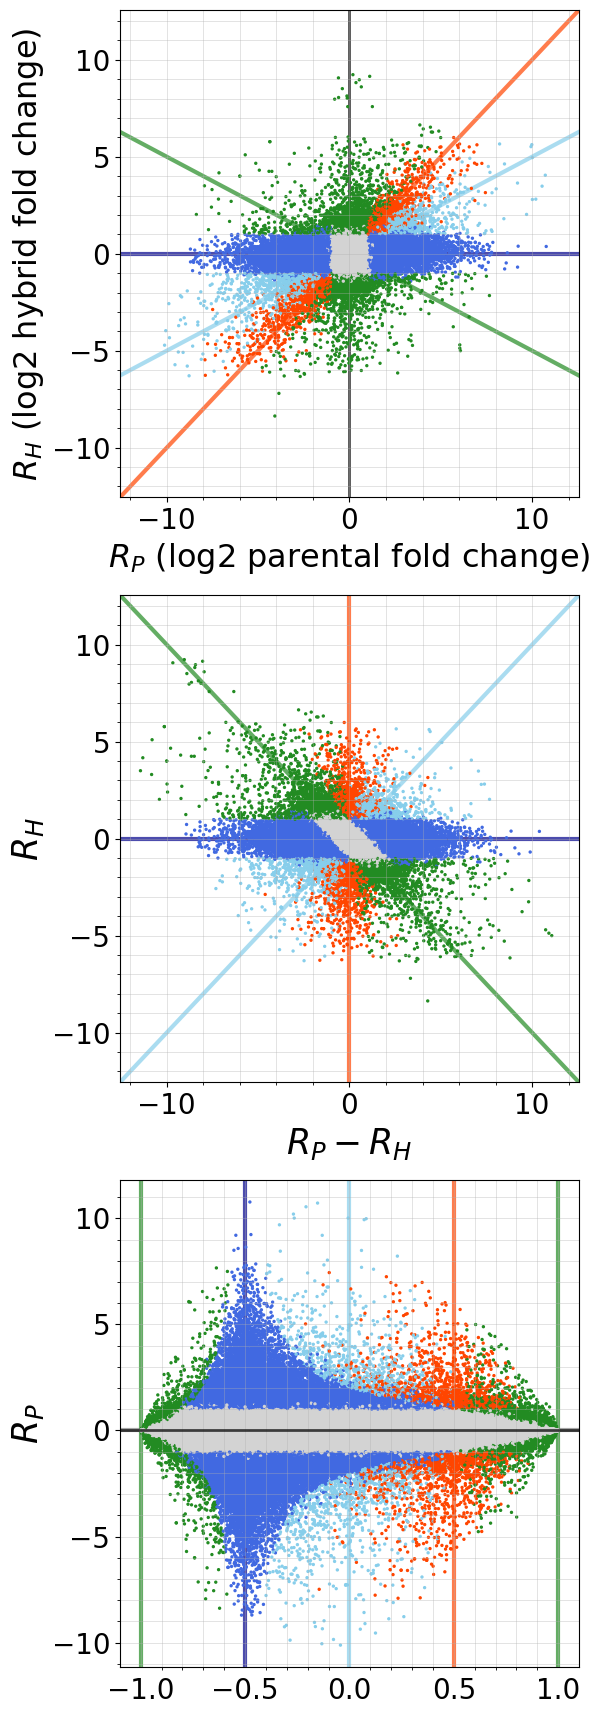

In [70]:
reg_groups = ['cis x trans','cis + trans','trans','cis','conserved']

# random order
fig, ax = plt.subplots(3, 1, figsize=(6, 23*(3/4)))

s = 2
alpha = 1.0
axis_fs = 25
title_fs = 18
label_fs = 20
line_color = 'black'
axis_width = 3.0
line_alpha = 0.7

P = df['Parlog2FC'].values.flatten()
H = df['Hyblog2FC'].values.flatten()
delta = P - H
theta_scaled = (2/np.pi) * np.arctan(H / delta)
R = np.sqrt(delta**2 + H**2)
cis_prop_reordered = theta_scaled-0.5
cis_prop_reordered[cis_prop_reordered<=-1.0] = (cis_prop_reordered[cis_prop_reordered<=-1.0]) + 2.0

colors = df['color_reported'].values

random_idx = np.arange(0,len(colors))
np.random.shuffle(random_idx)


ax[0].scatter(P[random_idx],H[random_idx],s = s, alpha = alpha, c = colors[random_idx])
ax[0].set_xlabel('$R_P$ (log2 parental fold change)', fontsize = axis_fs-2)
ax[0].set_ylabel('$R_H$ (log2 hybrid fold change)', fontsize = axis_fs-2)

ax[1].scatter(P[random_idx]-H[random_idx],H[random_idx],s=s,alpha=alpha,  c = colors[random_idx])
ax[1].set_xlabel('$R_P - R_H$',fontsize = axis_fs)
ax[1].set_ylabel('$R_H$',fontsize = axis_fs)

ax[2].scatter(cis_prop_reordered[random_idx], P[random_idx] ,s = s, alpha = alpha, c=colors[random_idx])
# ax[2].set_xlabel(r'(scaled angle from axis)',fontsize=axis_fs)
ax[2].set_ylabel('$R_P$',fontsize=axis_fs)

for i in range(2):
    # ax[i].set_xlabel(ax[i].get_xlabel(), fontsize=axis_fs)
    # ax[i].set_ylabel(ax[i].get_ylabel(), fontsize=axis_fs)
    ax[i].tick_params(axis='both', labelsize=label_fs)
    ax[i].grid(which='both', alpha=0.5, linewidth=0.5)
    ax[i].minorticks_on()


# Determine the diagonal points for the line y = x
x_min, x_max = ax[i].get_xlim()
y_min, y_max = ax[i].get_ylim()
diag_val = max( np.abs(x_min), np.abs(x_max), np.abs(y_min), np.abs(y_max) )


x = np.linspace(-diag_val, diag_val, 100)
ax_ = ax[0]
ax_.plot(x, x, color='orangered', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.plot(x+x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.plot(-x-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)
# ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')
ax_.axvline(0, color='black', linewidth=2, alpha=0.7, linestyle='-',zorder=0)
ax_.set_xlim(-diag_val, diag_val)
ax_.set_ylim(-diag_val, diag_val)

ax_ = ax[1]
ax_.axvline(0, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha = line_alpha,zorder=0)
ax_.plot(x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.plot(-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.set_xlim(-diag_val, diag_val)
ax_.set_ylim(-diag_val, diag_val)

# Set additional grid lines for the third plot
ax_ = ax[2]
ax_.axvline(0.5, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(-0.5, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(0.0, color='skyblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(-1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axhline(0, color='gray', linewidth=axis_width, alpha = line_alpha,zorder=0)
ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')

ax[2].tick_params(axis='both', labelsize=label_fs)
ax[2].tick_params(bottom=False)
ax[2].grid(which='both', alpha=0.5, linewidth=0.5)
ax[2].minorticks_on()

ax2_xlims = ax[2].get_xlim()
ax2_ylims = ax[2].get_ylim()

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.savefig('figs/fig2A',dpi=450,bbox_inches='tight',pad_inches=0.3)
plt.show();


cis x trans 6696


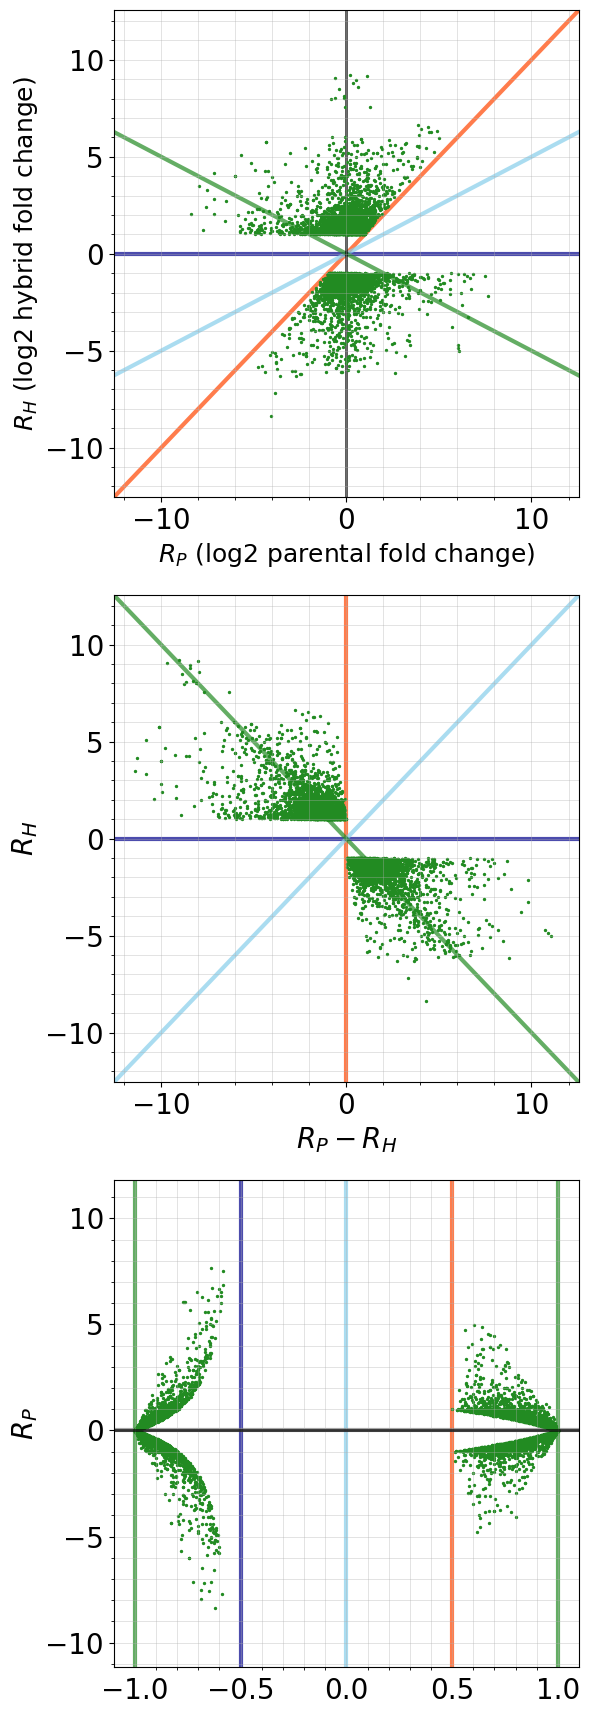

cis + trans 1727


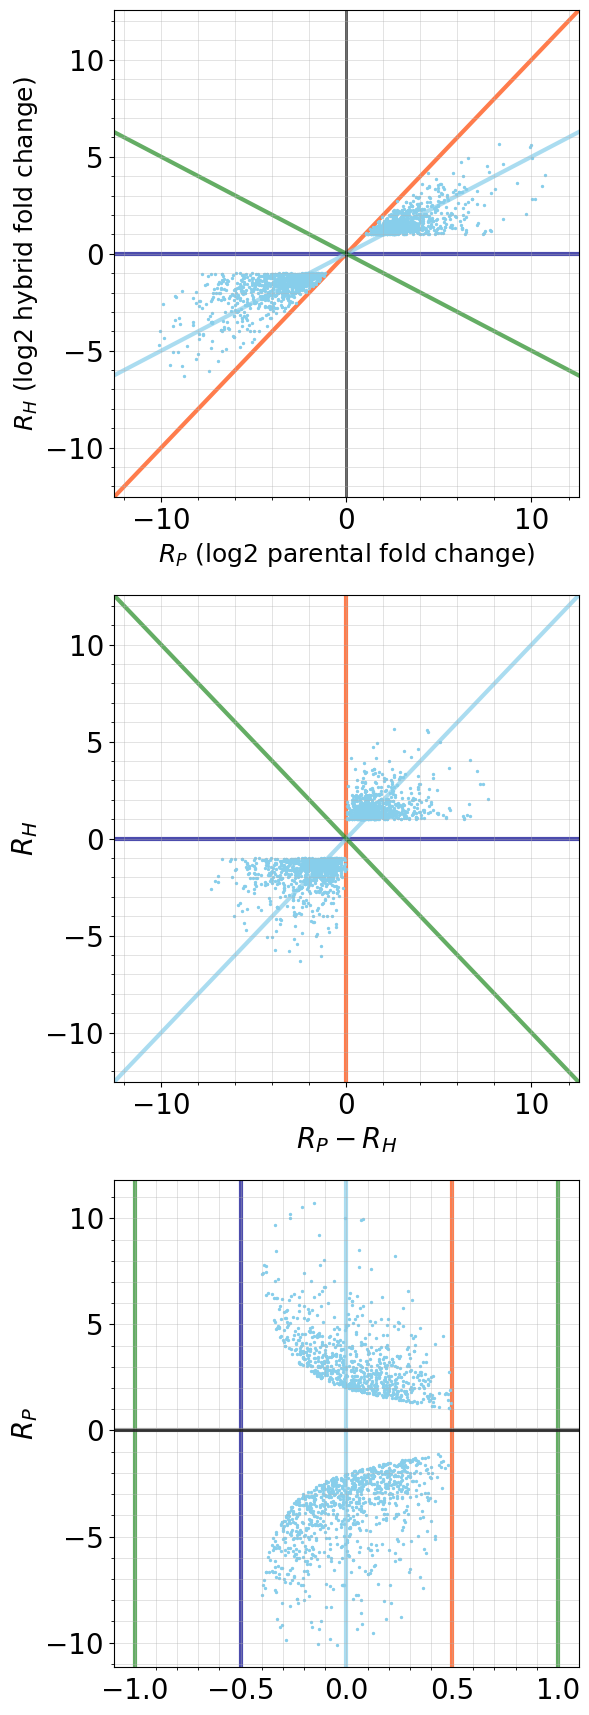

trans 57253


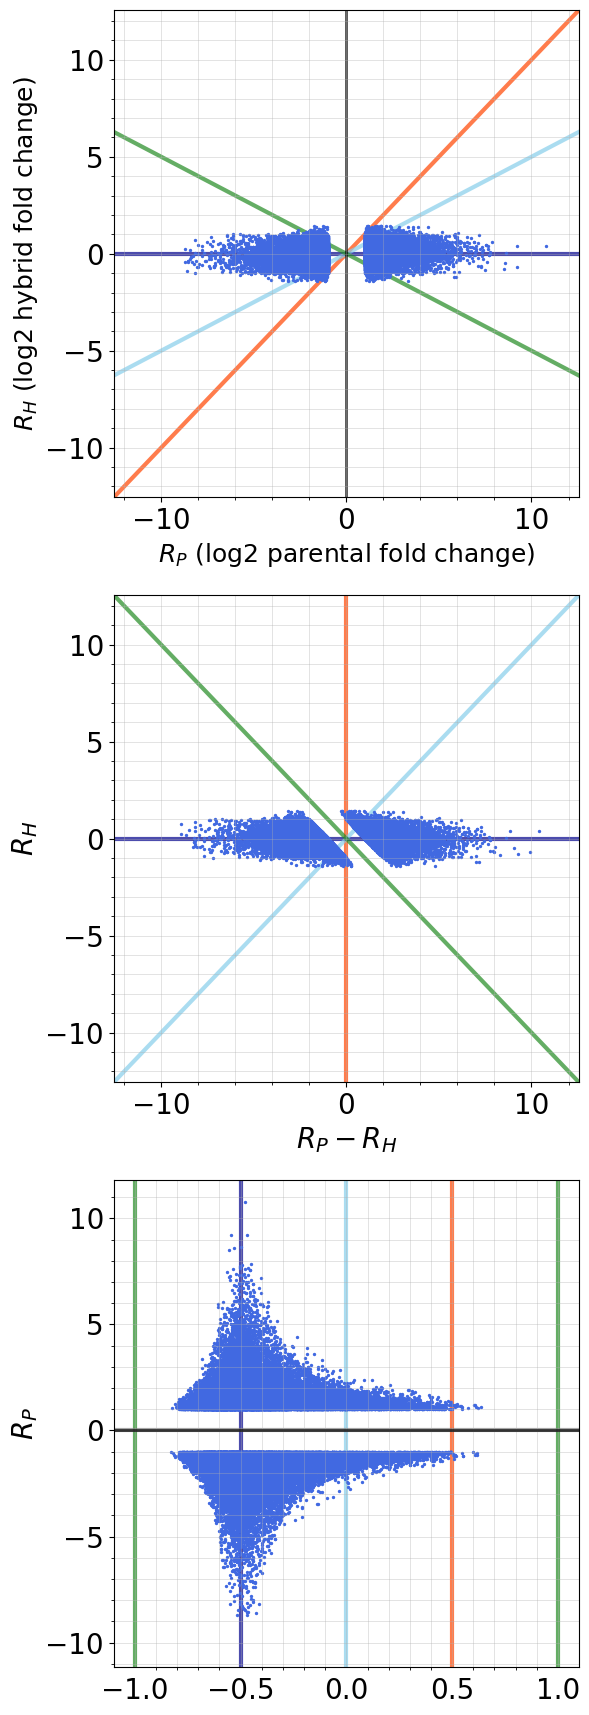

cis 2804


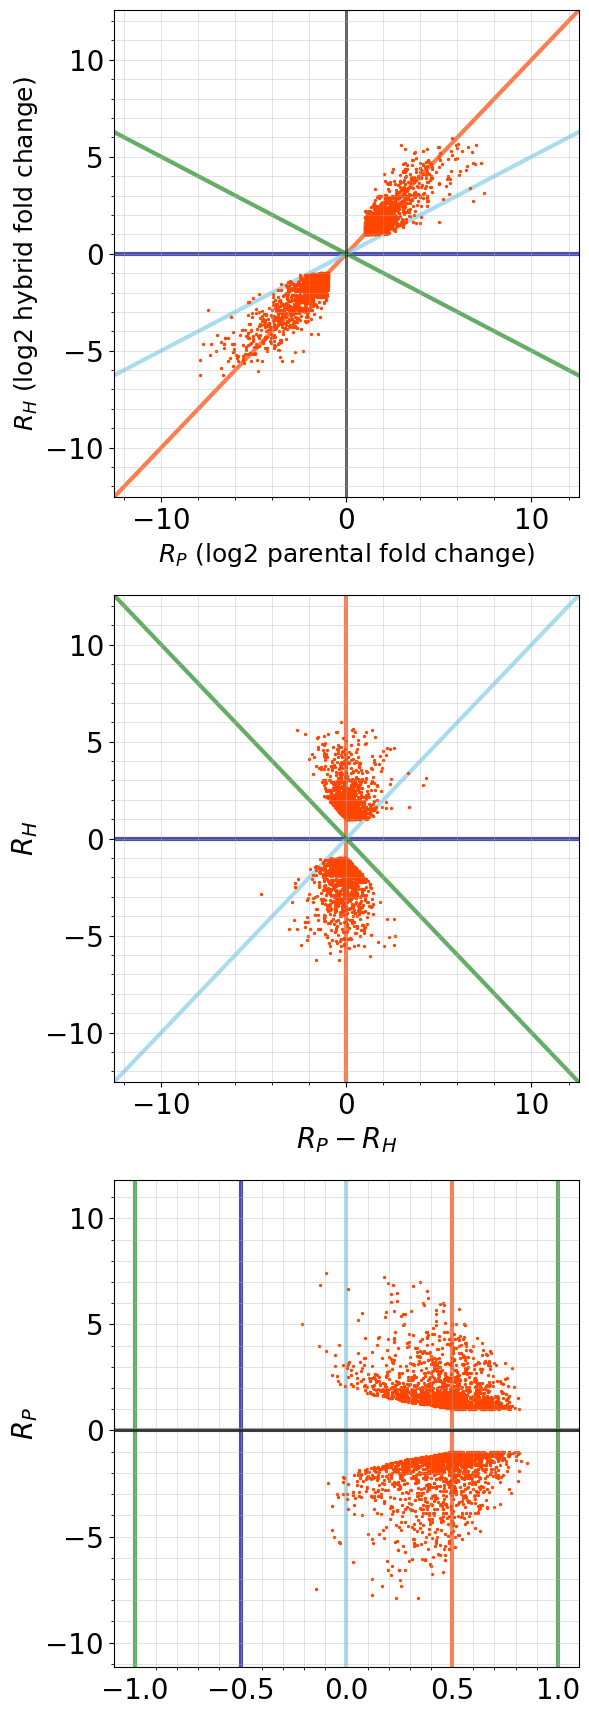

conserved 217297


/tmp/ipykernel_11531/2576754963.py:15: RuntimeWarning: invalid value encountered in divide
  theta_scaled = (2/np.pi) * np.arctan(H / delta)


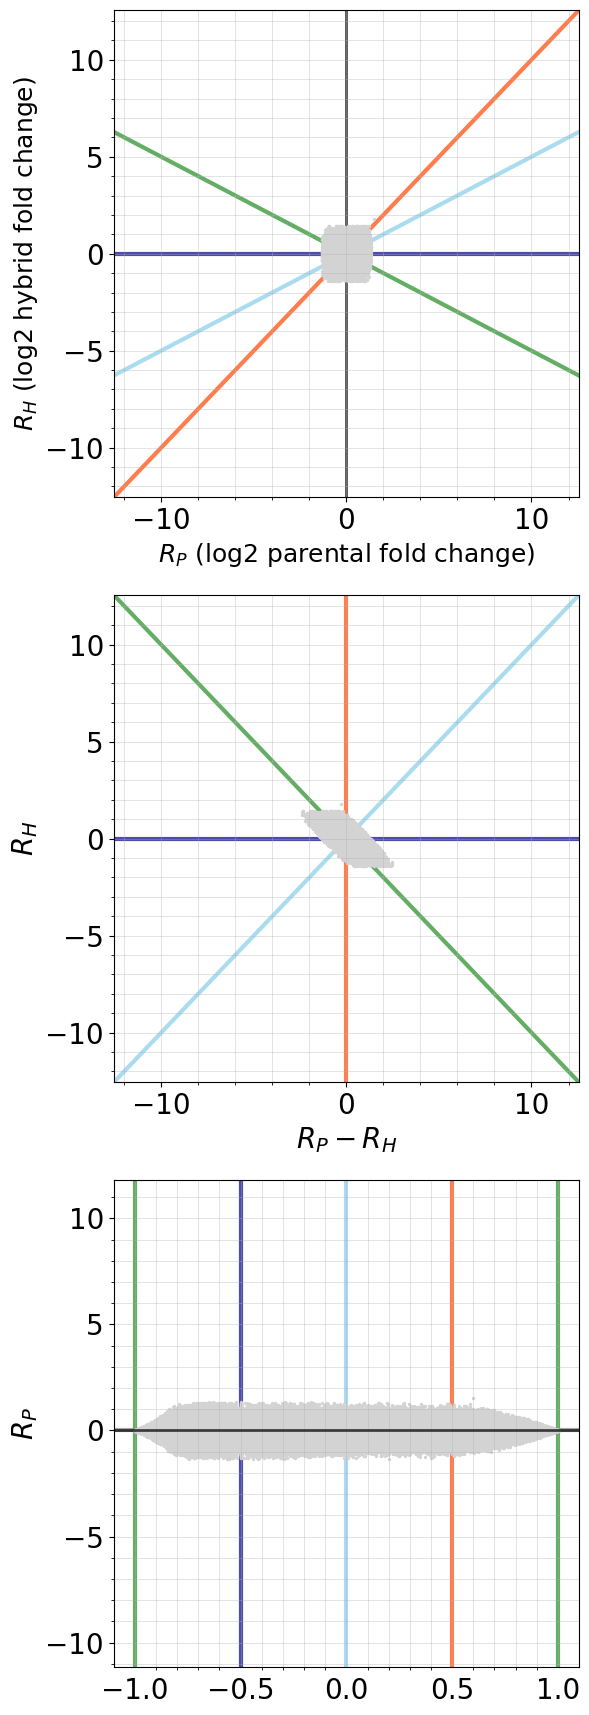

In [63]:
num_per_reg_group_theirs = []
colors = []

for reg in reg_groups:
    fig, ax = plt.subplots(3, 1, figsize=(6, 23*(3/4)))
    label = label_dict[reg]
    color = color_dict[reg]
    df_ = df[df['new_reg_group_theirs'] == reg]
    P = df_['Parlog2FC'].values.flatten()
    H = df_['Hyblog2FC'].values.flatten()
    num_per_reg_group_theirs.append(len(H))
    colors.append(color)
    print(reg,len(P))
    delta = P - H
    theta_scaled = (2/np.pi) * np.arctan(H / delta)
    R = np.sqrt(delta**2 + H**2)
    cis_prop_reordered = theta_scaled-0.5
    cis_prop_reordered[cis_prop_reordered<=-1.0] = (cis_prop_reordered[cis_prop_reordered<=-1.0]) + 2.0

    ax[0].scatter(P,H,s = s, alpha = alpha, color = color, label = label)
    ax[0].set_xlabel('$R_P$ (log2 parental fold change)', fontsize = axis_fs-2)
    ax[0].set_ylabel('$R_H$ (log2 hybrid fold change)', fontsize = axis_fs-2)

    ax[1].scatter(P-H,H,s=s,alpha=alpha,  color = color)
    ax[1].set_xlabel('$R_P - R_H$',fontsize = axis_fs)
    ax[1].set_ylabel('$R_H$',fontsize = axis_fs)

    ax[2].scatter(cis_prop_reordered, P ,s = s, alpha = alpha,color=color)
    # ax[2].set_xlabel(r'(scaled angle from axis)',fontsize=axis_fs)
    ax[2].set_ylabel('$R_P$',fontsize=axis_fs)

    for i in range(2):
        # ax[i].set_xlabel(ax[i].get_xlabel(), fontsize=axis_fs)
        # ax[i].set_ylabel(ax[i].get_ylabel(), fontsize=axis_fs)
        ax[i].tick_params(axis='both', labelsize=label_fs)
        ax[i].grid(which='both', alpha=0.5, linewidth=0.5)
        ax[i].minorticks_on()

        ax[i].set_xlim(-diag_val, diag_val)
        ax[i].set_ylim(-diag_val, diag_val)


    x = np.linspace(-diag_val, diag_val, 100)
    ax_ = ax[0]
    ax_.plot(x, x, color='orangered', linewidth=axis_width,alpha = line_alpha,zorder=0)
    ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.plot(x+x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
    ax_.plot(-x-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)
    # ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')
    ax_.axvline(0, color='black', linewidth=2, alpha=0.7, linestyle='-',zorder=0)

    ax_ = ax[1]
    ax_.axvline(0, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha = line_alpha,zorder=0)
    ax_.plot(x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
    ax_.plot(-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)



    # Set additional grid lines for the third plot
    ax_ = ax[2]
    ax_.axvline(0.5, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(-0.5, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(0.0, color='skyblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(-1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axhline(0, color='gray', linewidth=axis_width, alpha = line_alpha,zorder=0)
    ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')

    ax[2].tick_params(axis='both', labelsize=label_fs)
    ax[2].tick_params(bottom=False)
    ax[2].grid(which='both', alpha=0.5, linewidth=0.5)
    ax[2].minorticks_on()

    ax[2].set_xlim(ax2_xlims)
    ax[2].set_ylim(ax2_ylims)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    plt.savefig(f'supp2B_{reg}',dpi=450,bbox_inches='tight')
    plt.show();


/tmp/ipykernel_11531/2508171438.py:18: RuntimeWarning: invalid value encountered in divide
  theta_scaled = (2/np.pi) * np.arctan(H / delta)


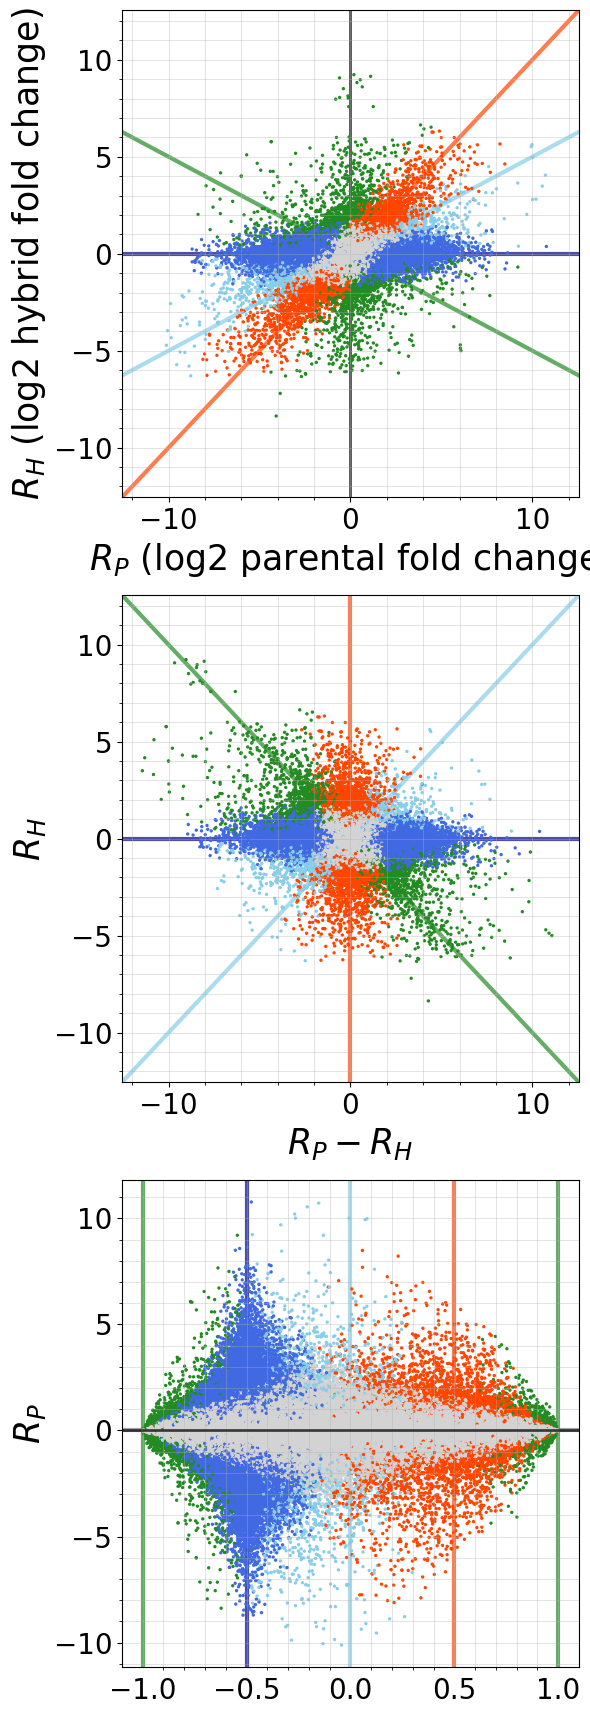

In [64]:
## Transformed regulatory assignments

# random order
fig, ax = plt.subplots(3, 1, figsize=(6, 23*(3/4)))

s = 2
alpha = 1.0
axis_fs = 25
title_fs = 18
label_fs = 20
line_color = 'black'
axis_width = 3.0


P = df['Parlog2FC'].values.flatten()
H = df['Hyblog2FC'].values.flatten()
delta = P - H
theta_scaled = (2/np.pi) * np.arctan(H / delta)
R = np.sqrt(delta**2 + H**2)
cis_prop_reordered = theta_scaled-0.5
cis_prop_reordered[cis_prop_reordered<=-1.0] = (cis_prop_reordered[cis_prop_reordered<=-1.0]) + 2.0

colors = df['color_fdr'].values

random_idx = np.arange(0,len(colors))
np.random.shuffle(random_idx)


ax[0].scatter(P[random_idx],H[random_idx],s = s, alpha = alpha, c = colors[random_idx])
ax[0].set_xlabel('$R_P$ (log2 parental fold change)', fontsize = axis_fs-2)
ax[0].set_ylabel('$R_H$ (log2 hybrid fold change)', fontsize = axis_fs-2)



ax[1].scatter(P[random_idx]-H[random_idx],H[random_idx],s=s,alpha=alpha,  c = colors[random_idx])
ax[1].set_xlabel('$R_P - R_H$',fontsize = axis_fs)
ax[1].set_ylabel('$R_H$',fontsize = axis_fs)


ax[2].scatter(cis_prop_reordered[random_idx], P[random_idx] ,s = s, alpha = alpha, c=colors[random_idx])
# ax[2].set_xlabel(r'

#  (scaled angle from
#  axis)',fontsize=axis_fs)
ax[2].set_ylabel('$R_P$',fontsize=axis_fs)

for i in range(2):
    ax[i].set_xlabel(ax[i].get_xlabel(), fontsize=axis_fs)
    ax[i].set_ylabel(ax[i].get_ylabel(), fontsize=axis_fs)
    ax[i].tick_params(axis='both', labelsize=label_fs)
    ax[i].grid(which='both', alpha=0.5, linewidth=0.5)
    ax[i].minorticks_on()


# Determine the diagonal points for the line y = x
x_min, x_max = ax[i].get_xlim()
y_min, y_max = ax[i].get_ylim()
diag_val = max( np.abs(x_min), np.abs(x_max), np.abs(y_min), np.abs(y_max) )



x = np.linspace(-diag_val, diag_val, 100)
ax_ = ax[0]
ax_.plot(x, x, color='orangered', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.plot(x+x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.plot(-x-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)
# ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')
ax_.axvline(0, color='black', linewidth=2, alpha=0.7, linestyle='-',zorder=0)
ax_.set_xlim(-diag_val, diag_val)
ax_.set_ylim(-diag_val, diag_val)

ax_ = ax[1]
ax_.axvline(0, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha = line_alpha,zorder=0)
ax_.plot(x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.plot(-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)
ax_.set_xlim(-diag_val, diag_val)
ax_.set_ylim(-diag_val, diag_val)

# Set additional grid lines for the third plot
ax_ = ax[2]
ax_.axvline(0.5, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(-0.5, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(0.0, color='skyblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(-1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axvline(1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
ax_.axhline(0, color='gray', linewidth=axis_width, alpha = line_alpha,zorder=0)
ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')

ax[2].tick_params(axis='both', labelsize=label_fs)
ax[2].tick_params(bottom=False)
ax[2].grid(which='both', alpha=0.5, linewidth=0.5)
ax[2].minorticks_on()


ax2_xlims = ax[2].get_xlim()
ax2_ylims = ax[2].get_ylim()

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.savefig('figs/fig2C',dpi=450,bbox_inches='tight')
plt.show();

cis x trans 5393


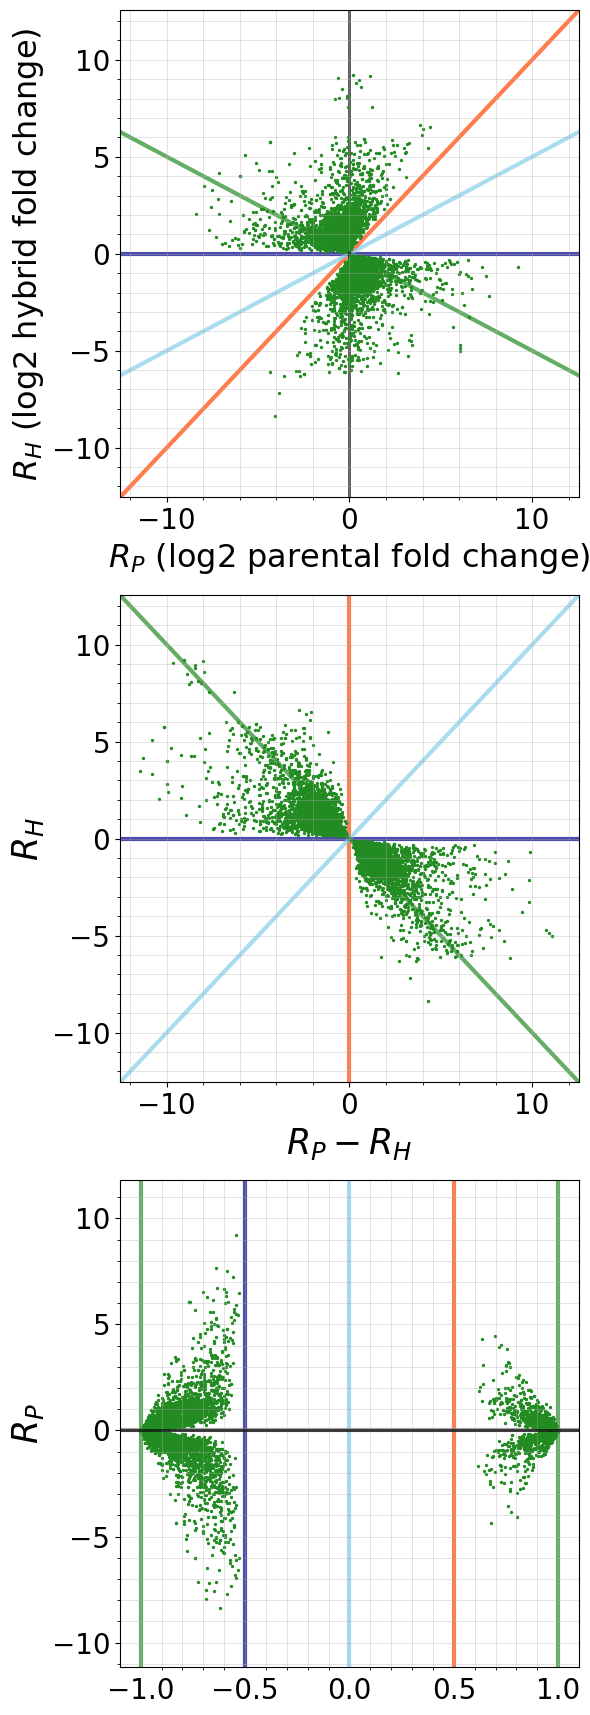

cis + trans 2313


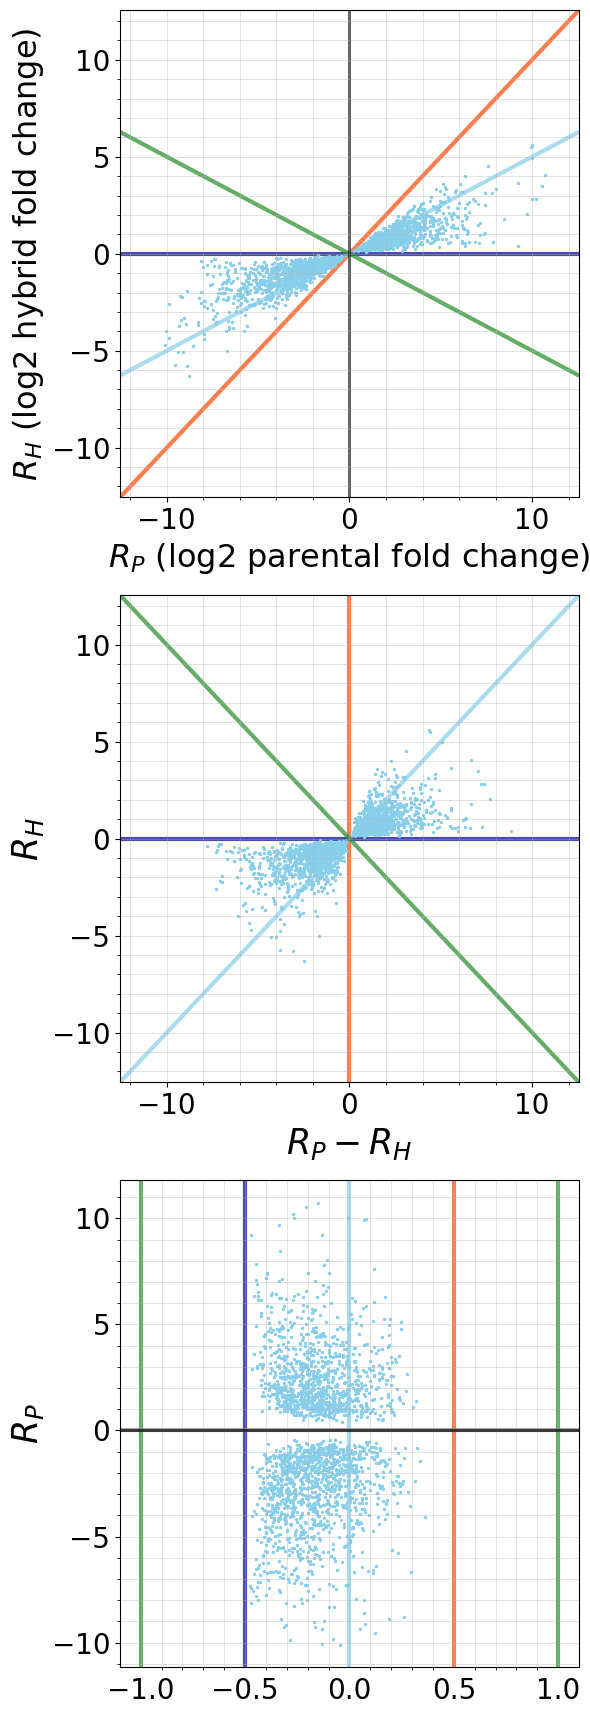

trans 39063


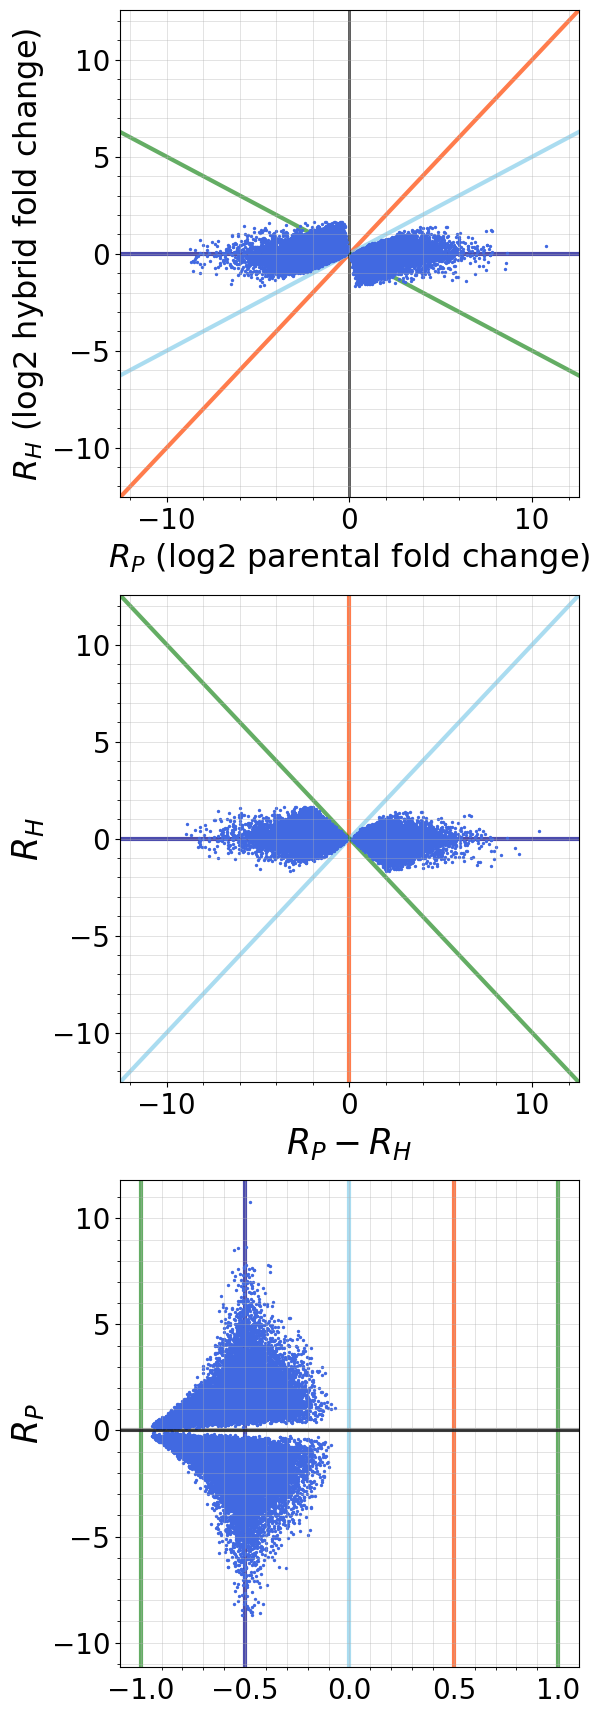

cis 7441


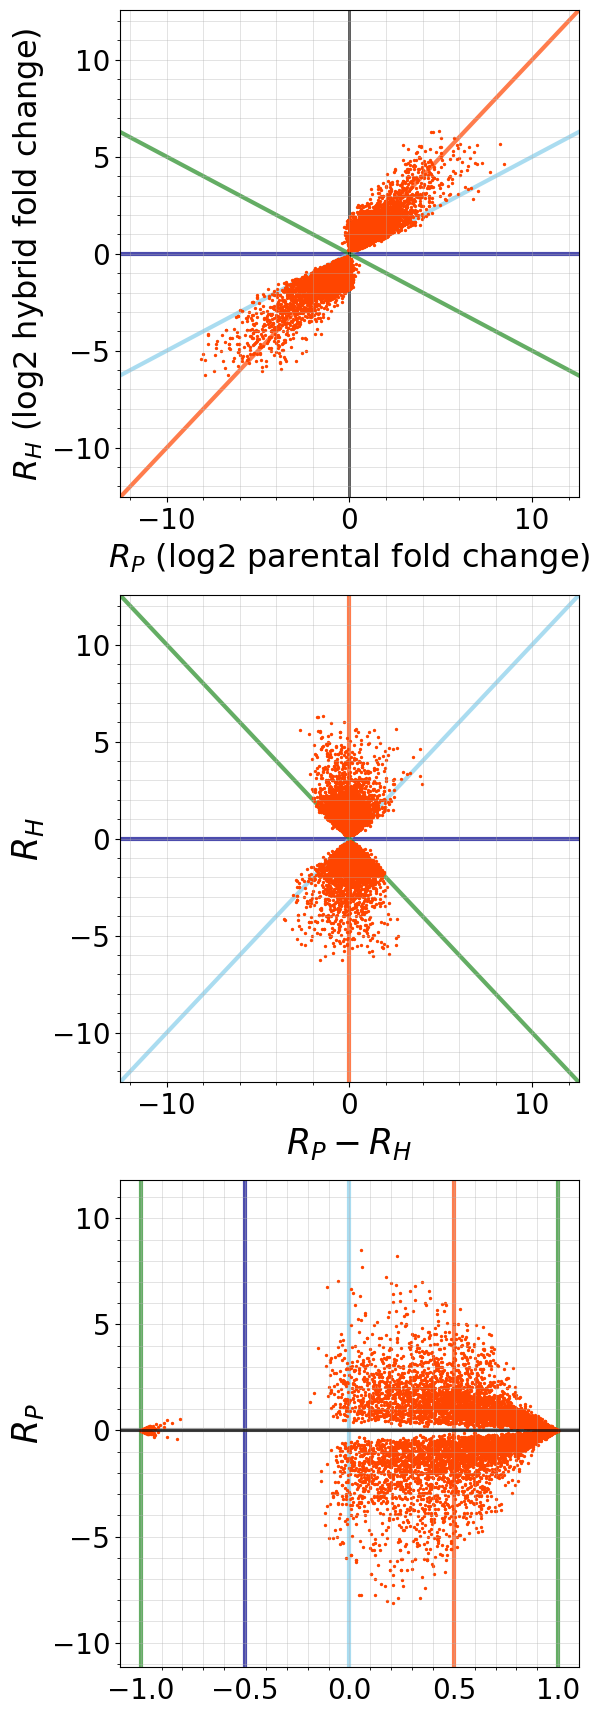

conserved 231567


/tmp/ipykernel_11531/3407248418.py:24: RuntimeWarning: invalid value encountered in divide
  theta_scaled = (2/np.pi) * np.arctan(H / delta)


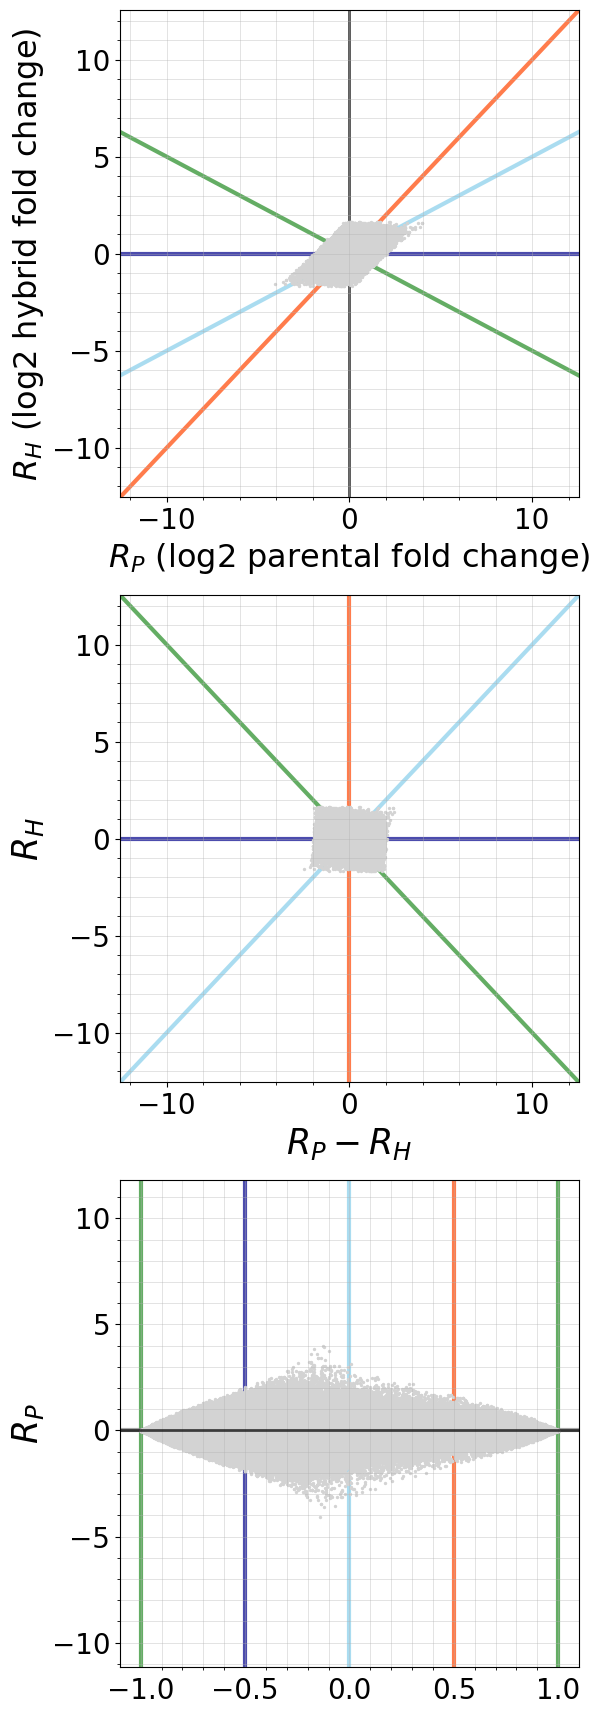

In [65]:
s = 2
alpha = 1.0
axis_fs = 25
title_fs = 18
label_fs = 20
line_color = 'black'
axis_width = 3.0
line_alpha = 0.7

num_per_reg_group_theirs = []
colors = []

for reg in reg_groups:
    fig, ax = plt.subplots(3, 1, figsize=(6, 23*(3/4)))
    label = label_dict[reg]
    color = color_dict[reg]
    df_ = df[df['new_reg_group_fdr'] == reg]
    P = df_['Parlog2FC'].values.flatten()
    H = df_['Hyblog2FC'].values.flatten()
    num_per_reg_group_theirs.append(len(H))
    colors.append(color)
    print(reg,len(P))
    delta = P - H
    theta_scaled = (2/np.pi) * np.arctan(H / delta)
    R = np.sqrt(delta**2 + H**2)
    cis_prop_reordered = theta_scaled-0.5
    cis_prop_reordered[cis_prop_reordered<=-1.0] = (cis_prop_reordered[cis_prop_reordered<=-1.0]) + 2.0

    # ax[0].scatter(P, H, s=s, alpha=alpha, color=color, label=label)
    # ax[1].scatter(delta, H, s=s, alpha=alpha, color=color)
    # ax[2].scatter(theta_scaled, P, s=s, alpha=alpha, color=color)
    # ax[2].scatter(theta_scaled, R, s=s, alpha=alpha, color=color)

    ax[0].scatter(P,H,s = s, alpha = alpha, color = color, label = label)
    ax[0].set_xlabel('$R_P$ (log2 parental fold change)', fontsize = axis_fs-2)
    ax[0].set_ylabel('$R_H$ (log2 hybrid fold change)', fontsize = axis_fs-2)

    ax[1].scatter(P-H,H,s=s,alpha=alpha,  color = color)
    ax[1].set_xlabel('$R_P-R_H$',fontsize = axis_fs)
    ax[1].set_ylabel('$R_H$',fontsize = axis_fs)

    ax[2].scatter(cis_prop_reordered, P ,s = s, alpha = alpha,color=color)
    # ax[2].set_xlabel(r'

#  (scaled angle from
#  axis)',fontsize=axis_fs)
    ax[2].set_ylabel('$R_P$',fontsize=axis_fs)

    for i in range(2):
        # ax[i].set_xlabel(ax[i].get_xlabel(), fontsize=axis_fs)
        # ax[i].set_ylabel(ax[i].get_ylabel(), fontsize=axis_fs)
        ax[i].tick_params(axis='both', labelsize=label_fs)
        ax[i].grid(which='both', alpha=0.5, linewidth=0.5)
        ax[i].minorticks_on()


        # Determine the diagonal points for the line y = x

        # ax[i].plot([-diag_val, diag_val], np.sqrt(3)*np.array([-diag_val, diag_val]), color='black',alpha=0.7,linestyle='--')
        # ax[i].plot([-diag_val, diag_val], np.sqrt(3)*np.array([diag_val, -diag_val]), color='black',alpha=0.7,linestyle='--')
        # ax[i].plot([-diag_val, diag_val], (1/np.sqrt(3))*np.array([-diag_val, diag_val]), color='black',alpha=0.7,linestyle='--')
        # ax[i].plot([-diag_val, diag_val], (1/np.sqrt(3))*np.array([diag_val, -diag_val]), color='black',alpha=0.7,linestyle='--')
        ax[i].set_xlim(-diag_val, diag_val)
        ax[i].set_ylim(-diag_val, diag_val)


    x = np.linspace(-diag_val, diag_val, 100)
    ax_ = ax[0]
    ax_.plot(x, x, color='orangered', linewidth=axis_width,alpha = line_alpha,zorder=0)
    ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.plot(x+x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
    ax_.plot(-x-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)
    # ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')
    ax_.axvline(0, color='black', linewidth=2, alpha=0.7, linestyle='-',zorder=0)

    ax_ = ax[1]
    ax_.axvline(0, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axhline(0, color='darkblue', linewidth=axis_width, alpha = line_alpha,zorder=0)
    ax_.plot(x, x, color='skyblue', linewidth=axis_width,alpha = line_alpha,zorder=0)
    ax_.plot(-x, x, color='forestgreen', linewidth=axis_width,alpha = line_alpha,zorder=0)



    # Set additional grid lines for the third plot
    ax_ = ax[2]
    ax_.axvline(0.5, color='orangered', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(-0.5, color='darkblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(0.0, color='skyblue', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(-1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axvline(1, color='forestgreen', linewidth=axis_width, alpha=line_alpha,zorder=0)
    ax_.axhline(0, color='gray', linewidth=axis_width, alpha = line_alpha,zorder=0)
    ax_.axhline(0, color='black', linewidth=2, alpha=0.7, linestyle='-')

    ax[2].tick_params(axis='both', labelsize=label_fs)
    ax[2].tick_params(bottom=False)
    ax[2].grid(which='both', alpha=0.5, linewidth=0.5)
    ax[2].minorticks_on()

    ax[2].set_xlim(ax2_xlims)
    ax[2].set_ylim(ax2_ylims)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    plt.savefig(f'supp2B_{reg}_fdr',dpi=450,bbox_inches='tight',pad_inches=0.3)
    plt.show();


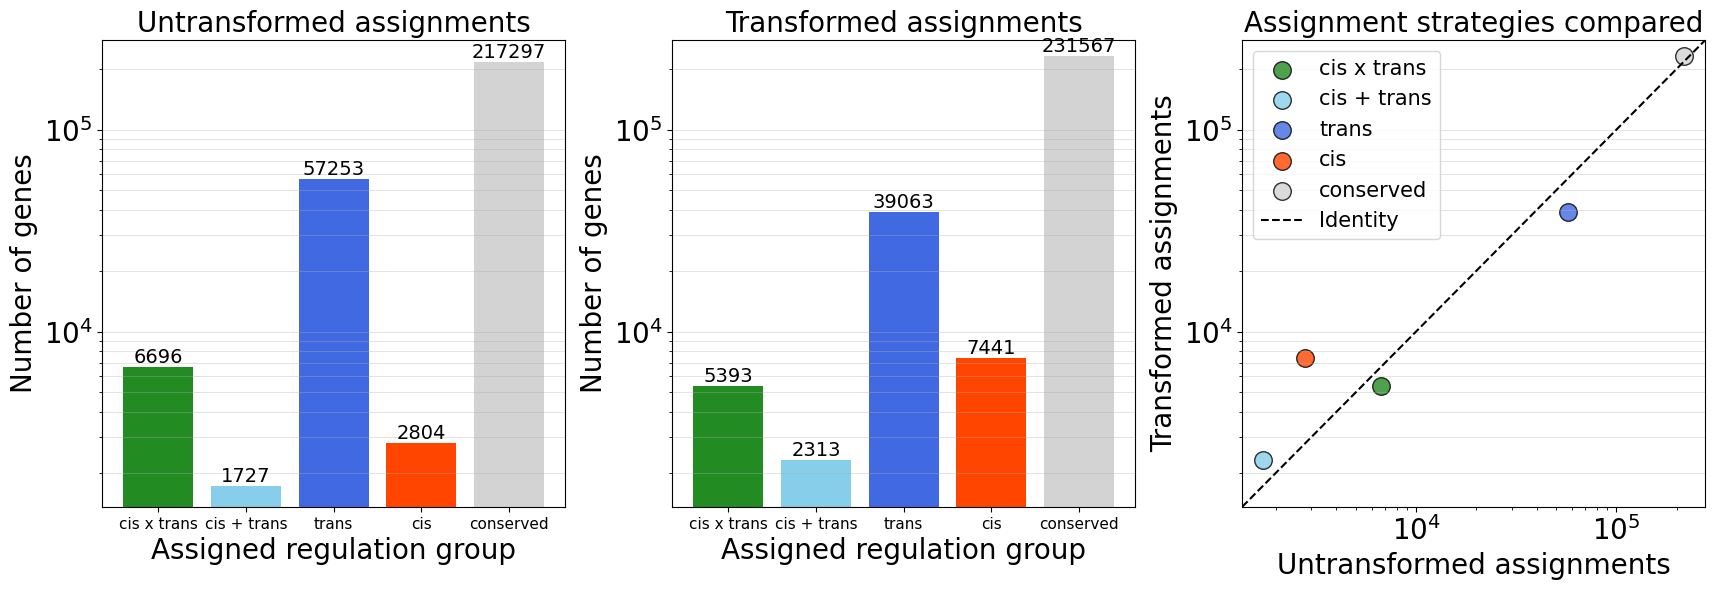

In [59]:
## Genes per regulatory assignment
reg_groups = ['cis x trans','cis + trans','trans','cis','conserved']
num_per_reg_group_theirs = []
num_per_reg_group_ours = []

for reg in reg_groups:
    num_per_reg_group_theirs.append(int(sum(df['new_reg_group_theirs']==reg)))
    num_per_reg_group_ours.append(int(sum(df['new_reg_group_fdr']==reg)))

colors = [color_dict[reg] for reg in reg_groups]

# barplot

fig, ax = plt.subplots(1,3,figsize = (5.75*3,6) )

axis_fs = 20
title_fs = 20
i = 0
bars = ax[i].bar(range(len(num_per_reg_group_theirs)), num_per_reg_group_theirs, color=colors)

for bar in bars:
  height = bar.get_height()
  ax[i].text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}',
             ha='center', va='bottom', fontsize=14)

ax[i].set_xticks(range(len(num_per_reg_group_theirs)))
ax[i].set_xticklabels(reg_groups,fontsize=axis_fs-4)
ax[i].set_xlabel('Assigned regulation group',fontsize=axis_fs)
ax[i].set_ylabel('Number of genes',fontsize= axis_fs)
ax[i].set_yscale('log')
ax[i].yaxis.grid(which='both', alpha=0.5, linewidth=0.5)
ax[i].minorticks_on()
ax[i].xaxis.set_tick_params(which='minor', bottom=False)
ax[i].set_title('Untransformed assignments',fontsize=title_fs)
i = 1
bars = ax[i].bar(range(len(num_per_reg_group_ours)), num_per_reg_group_ours, color=colors)

for bar in bars:
  height = bar.get_height()
  ax[i].text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}',
             ha='center', va='bottom',fontsize=14)

ax[i].set_xticks(range(len(num_per_reg_group_ours)))
ax[i].set_xticklabels(reg_groups,fontsize=axis_fs-4)
ax[i].set_xlabel('Assigned regulation group',fontsize=axis_fs)
ax[i].set_ylabel('Number of genes',fontsize= axis_fs)
ax[i].set_yscale('log')
ax[i].yaxis.grid(which='both', alpha=0.5, linewidth=0.5)
ax[i].minorticks_on()
ax[i].xaxis.set_tick_params(which='minor', bottom=False)
ax[i].set_title('Transformed assignments',fontsize=title_fs)
ax[i].set_ylim(ax[0].get_ylim())

i = 2
for r,reg in enumerate(reg_groups):

    ax[i].scatter(num_per_reg_group_theirs[r],num_per_reg_group_ours[r],
                  color = colors[r],s=160,alpha=0.8,
                  edgecolor='black',label=reg)

ax[i].set_xscale('log')
ax[i].set_yscale('log')
ax[i].set_xlabel('Untransformed assignments',fontsize=axis_fs)
ax[i].set_ylabel('Transformed assignments',fontsize=axis_fs)
ax[i].set_title('Assignment strategies compared',fontsize=axis_fs)
ax[i].yaxis.grid(which='both', alpha=0.5, linewidth=0.5)
ax[i].minorticks_on()
lims = ax[i].get_xlim()
ax[i].plot(lims,lims,color='black',linestyle='--',label='Identity')
ax[i].legend(fontsize=15)


ax[i].set_ylim(lims)
ax[i].set_xlim(lims)


for ax_ in ax:
    ax_.tick_params(axis='x', which='major', labelsize=11)
    ax_.tick_params(axis='y', which='major', labelsize=20)
ax[2].tick_params(axis='both', which='major', labelsize=20)

plt.tight_layout()
plt.savefig('./figs/supp_reg_assignments_bar',dpi=450,bbox_inches='tight')
plt.show()

# Alluvial plot

In [66]:
# download from https://github.com/vinsburg/alluvial_diagram/tree/master
!wget https://raw.githubusercontent.com/vinsburg/alluvial_diagram/master/alluvial.py



--2026-05-20 22:17:49--  https://raw.githubusercontent.com/vinsburg/alluvial_diagram/master/alluvial.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12728 (12K) [text/plain]
Saving to: ‘alluvial.py.1’

alluvial.py.1       100%[===================>]  12.43K  --.-KB/s    in 0s      

2026-05-20 22:17:49 (80.4 MB/s) - ‘alluvial.py.1’ saved [12728/12728]



In [67]:

import alluvial

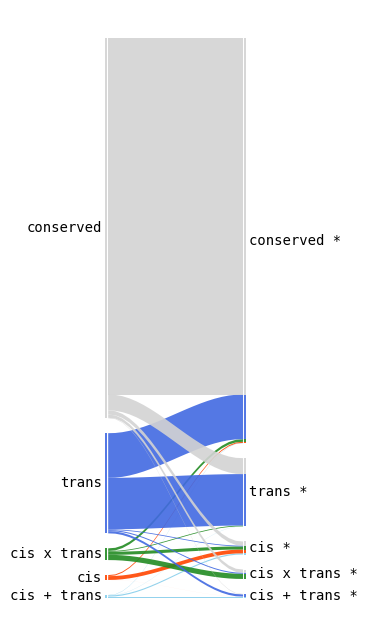

In [68]:
num_overlap_dict = {r : {} for r in reg_groups}

log_num_overlap_dict = {r : {} for r in reg_groups}

for r1 in reg_groups:
  their_indices = df[df['new_reg_group_theirs'] == r1].index.values.flatten()
  for r2 in reg_groups:
    our_indices = df[df['new_reg_group_fdr'] == r2 ].index.values.flatten()
    num_overlap = len(set(their_indices).intersection(set(our_indices)))
    num_overlap_dict[r1][r2+' * '] = num_overlap
    if num_overlap!= 0:
      log_num_overlap_dict[r1][r2+' * '] = np.log(num_overlap)
    else:
      log_num_overlap_dict[r1][r2+' * '] = 0


alluvial_colors = ['skyblue','orangered','forestgreen','royalblue','lightgray']
ax = alluvial.plot(num_overlap_dict,colors=alluvial_colors,alpha = 0.9)
fig = ax.get_figure()
fig.set_size_inches(2,8)
plt.savefig('alluvian',dpi=450,bbox_inches='tight')
plt.show()

In [ ]:
b